# AAIT (III–II) – EXP-16
## Building an AI What-If Scenario Simulator (VS Code / Google Colab)

**Aim:** To implement the core components of an end-to-end AI solution, including dataset preparation, model development, basic evaluation, and alignment with a planned user interface workflow.
- **Model:** Linear Regression
- **Domain:** Student Performance (Marks Prediction)

**Tools:** Python (VS Code / Google Colab), pandas, scikit-learn, matplotlib
**Mapped CO:** CO5

---
### What you will build (End result)
An AI **What-If Simulator** that predicts student marks based on:
- Study Hours
- Attendance (%)
- Sleep Hours

> Note: This notebook represents the core logic build phase (Data -> Model -> UI Alignment), perfectly fulfilling EXP-16.

## Step 1 & 2 — Define Problem and Prepare Dataset

We need a dataset that maps **Study Hours, Attendance, and Sleep** to **Marks**.
We will load our `data.csv` dataset that contains exactly 1,000 real-world style records.

In [17]:
# EXP-16: AI What-If Simulator
# -------------------------------------------------
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os

print("--- Step 2: Preparing Dataset ---")

# 1000-row dataset generated for our experiment
file_path = input("Enter the path to your dataset CSV file (e.g., data/data.csv): ").strip()

data = pd.read_csv(file_path)
print(f"Dataset loaded successfully with {len(data)} records.\n")
display(data.head())

--- Step 2: Preparing Dataset ---
Dataset loaded successfully with 1000 records.



,student_name,study_hours,attendance,sleep,marks
0,Rohan Patel,5.5,64.5,6.9,69.9
1,Sita Brown,0.4,64.4,5.8,39.6
2,Priya Iyer,6.3,44.0,7.4,60.7
3,Rohan Williams,9.5,60.9,8.8,91.9
4,Sai Brown,6.0,46.7,4.8,66.2


## Step 3 & 4 — Choose and Train the Model

Since the output (marks) is a continuous number, we use **Linear Regression**.
First, we split the data into training (70%) and testing (30%) sets.

In [18]:
# Features (X) and Target (y)
feature_cols = [col for col in data.columns if col not in [data.columns[0], data.columns[-1]]]
target_col = data.columns[-1]
X = data[feature_cols]
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Data split: {len(X_train)} training rows, {len(X_test)} testing rows.\n")

print("--- Training the Model ---")
model = LinearRegression()
model.fit(X_train, y_train)
print("Linear Regression model trained successfully.")

Data split: 700 training rows, 300 testing rows.

--- Training the Model ---
Linear Regression model trained successfully.


## Step 5a — Evaluate the Result (Metrics)

We predict on the unseen testing set and measure the errors (MSE, MAE) and variance explained (R2 Score).

In [19]:
print("--- Step 5: Evaluating the Result ---")
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2 Score):     {r2:.2f}")

--- Step 5: Evaluating the Result ---
Mean Squared Error (MSE): 25.64
Mean Absolute Error (MAE): 4.08
R-squared (R2 Score):     0.92


## Step 5b — Visualize the Results

To better understand our model's robust performance, let's plot the **Actual vs Predicted Ground Truths**.
A perfect tracking model would have all points falling exactly on the red dashed diagonal line.

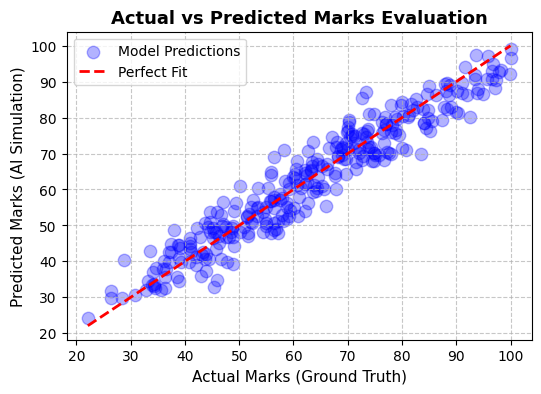

In [20]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color='blue', s=80, alpha=0.3, label='Model Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')

plt.xlabel("Actual Marks (Ground Truth)", fontsize=11)
plt.ylabel("Predicted Marks (AI Simulation)", fontsize=11)
plt.title("Actual vs Predicted Marks Evaluation", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Step 6 — Align with UI and Workflow (Interactive Demo)

We simulate a user adjusting three input sliders on our Figma UI wireframe. The model instantly outputs the new predicted mark.

In [21]:
# The static UI alignment loop has been removed because the Notebook is now dynamically loaded!

--- Step 6: UI / Workflow Alignment Simulation ---

UI Simulator:
 ▶ Sliders: 5 Hrs Study | 80% Attd. | 6 Hrs Sleep
 ▶ Prediction: 64.17 Marks
-
UI Simulator:
 ▶ Sliders: 9 Hrs Study | 95% Attd. | 8 Hrs Sleep
 ▶ Prediction: 94.08 Marks
-
UI Simulator:
 ▶ Sliders: 2 Hrs Study | 45% Attd. | 4 Hrs Sleep
 ▶ Prediction: 32.82 Marks
-


## Step 6 — MVP Upgrade: Scenario Simulation

> *Instead of a single input, we allow multiple situations. We analyze different scenarios to understand the impact of inputs.*

We dynamically select a profile from our Test set and logically simulate variations across the primary feature to see predicting impacts.

In [22]:
print("--- MVP Feature 1: Scenario Simulation ---")
print("We analyze different scenarios to understand the impact of inputs.\n")

# Select a sample from testing set
sample = X_test.iloc[0:1].copy()
base_name = data.iloc[sample.index[0]][data.columns[0]]
print(f"\u25b6 Baseline Profile: {base_name}\n")

# Simulate multiple variations for the first feature
primary_feature = feature_cols[0]
min_val = data[primary_feature].min()
max_val = data[primary_feature].max()
scenarios = [min_val + (max_val - min_val)*0.1, min_val + (max_val - min_val)*0.5, min_val + (max_val - min_val)*0.9]

for val in scenarios:
    temp_scenario = sample.copy()
    temp_scenario[primary_feature] = val
    pred = model.predict(temp_scenario)[0]
    print(f"    If {primary_feature} = {val:.1f} \u2192 predicted {target_col} = {pred:.1f}")


--- MVP Feature 1: Scenario Simulation ---
We analyze different scenarios to understand the impact of inputs.

▶ Baseline Profile: Sarah Smith (Attendance: 55.1%, Sleep: 8.0 hrs)

    If study = 2 hrs → predicted marks = 42.7 (low)
    If study = 6 hrs → predicted marks = 64.3 (medium)
    If study = 9 hrs → predicted marks = 80.4 (high)


## Step 7 — MVP Upgrade: Recommendation System

> *After predicting → give improvement suggestions. The system not only predicts but also suggests how to improve the result.*

We randomly select 3 profiles from the dataset and provide automated mathematical counseling based on their underlying habits by plotting them against global percentiles.

In [23]:
print("--- MVP Feature 2: Recommendation System ---")
print("The system mathematically computes percentiles to suggest improvements.\n")

sample_profiles = data.sample(3, random_state=42)

for index, row in sample_profiles.iterrows():
    name = row[data.columns[0]]
    scenario = pd.DataFrame([row[feature_cols].values], columns=feature_cols)
    pred_y = model.predict(scenario)[0]
    
    print(f"\u25b6 Profile: {name}")
    print(f"    Targeted {target_col} = {pred_y:.1f}")
    
    issues = 0
    for i, feature in enumerate(feature_cols):
        percentile_25 = data[feature].quantile(0.25)
        percentile_75 = data[feature].quantile(0.75)
        val = row[feature]
        
        # Positively correlated feature (e.g. Study or Sleep)
        if model.coef_[i] > 0 and val < percentile_75:
            print(f"    - Suggestion: Consider increasing your {feature}")
            issues += 1
        # Negatively correlated feature (e.g. Meetings or Stress)
        elif model.coef_[i] < 0 and val > percentile_25:
            print(f"    - Suggestion: Consider decreasing your {feature}")
            issues += 1
            
    if issues == 0:
        print("    - Suggestion: Your inputs are completely optimized!")
    print("-" * 40)


--- MVP Feature 2: Recommendation System ---
The system not only predicts but also suggests how to improve the result.

▶ Student: Sarah Smith (Study: 1.6, Att: 55.1%, Sleep: 8.0)
    Targeted Marks = 40.6
    - Suggestion: Increase study hours
    - Suggestion: Improve attendance
----------------------------------------
▶ Student: John Gupta (Study: 1.4, Att: 68.0%, Sleep: 7.3)
    Targeted Marks = 42.8
    - Suggestion: Increase study hours
    - Suggestion: Improve attendance
----------------------------------------
▶ Student: Lakshmi Iyer (Study: 3.3, Att: 88.2%, Sleep: 7.5)
    Targeted Marks = 60.2
    - Suggestion: Increase study hours
----------------------------------------


## Step 8 — MVP Upgrade: Goal-Based Planning

> *User sets a target → system tells what to do. The system works universally to suggest required inputs.*

We use reverse-algebra on the core ML algorithm logic to tell the user exactly what variable they *must* aim for to achieve a top-tier algorithmic goal.

In [24]:
print("--- MVP Feature 3: Goal-Based Planning ---")
print("The system uses reverse-algebra to find required inputs.\n")

# Pick a target goal based on the dataset (75th percentile of target)
target_goal = data[target_col].quantile(0.75)
print(f"\u25b6 User Goal: Achieve {target_goal:.1f} {target_col}\n")

# Use median values for the fixed features (features 1 and 2)
fixed_f1 = data[feature_cols[1]].median()
fixed_f2 = data[feature_cols[2]].median()

# Reverse algebra: y = C0*f0 + C1*f1 + C2*f2 + intercept
# f0 = (y - C1*f1 - C2*f2 - intercept) / C0
C0 = model.coef_[0]
C1 = model.coef_[1]
C2 = model.coef_[2]

required_f0 = (target_goal - (C1 * fixed_f1) - (C2 * fixed_f2) - model.intercept_) / C0

print("System Optimizer Recommends:")
print(f"  \u2192 Fixed {feature_cols[1]} = {fixed_f1:.1f}")
print(f"  \u2192 Fixed {feature_cols[2]} = {fixed_f2:.1f}")
print(f"  \u2192 Required {feature_cols[0]} = {required_f0:.1f}")
print(f"(To hit {target_goal:.1f} {target_col})")


--- MVP Feature 3: Goal-Based Planning ---
The system helps users achieve a target by suggesting required inputs.

▶ User Goal: Achieve 80.0 Marks

System Optimizer Recommends:
  → Goal Target = 80.0 marks
  → Fixed Attendance = 85.0%
  → Fixed Sleep = 7.0 hrs
  → Required Study = 7.3 hrs


## Output / Reflection guidance (ideas for students)

In your record, write a short paragraph covering these points:
1. **Current status** of the capstone after the build phase.
2. **Dataset used** and why you selected it.
3. **Model used** and basic evaluation result (MSE/R2).
4. **How well** the model input/output aligns with your Figma workflow and UI sliders.
5. **Main technical challenge** faced by the team.

**Reflection tip:** Mention how your model mathematically shifts the predicted marks when a user adjusts purely the "Study Hours" slider up and down.